# PEP725 Fruit-Tree Flowering — Schaber & Badeck Outlier Detection

Applies a Schaber & Badeck-style outlier detector to the flowering
observations (`BBCH_60`) of the nine fruit-tree species used by
`build_pep725_fruit_trees`, and reports how many outliers it flags per
species.

## What Schaber & Badeck did (in spirit)

Schaber & Badeck (around 2002, on the German DWD phenological network that
later became part of PEP725) argued that a good outlier detector for
phenology should compare each observation against an *expected* value built
from the rest of the dataset — both **temporal context** ("how does this
station usually behave?") and **between-year context** ("how does this
year compare to other years across the network?"). The cleanest version of
that idea is a two-way additive decomposition:

$$y_{s,t} \;=\; \mu + \alpha_s + \beta_t + \varepsilon_{s,t}$$

where $\alpha_s$ is a *station effect* (this site blooms early/late), $\beta_t$
is a *year effect* (this year was warm/cold network-wide), and $\varepsilon_{s,t}$
is the residual. An observation is flagged when its residual is large
relative to the residual distribution.

Fitting via medians (Tukey's *median polish*) rather than means makes the
decomposition robust to the very outliers we're trying to detect, and
iterating — flag, refit on un-flagged data, re-flag — prevents bad points
from contaminating the station/year effect estimates.

**Caveat.** This is a reconstruction of the *spirit* of Schaber & Badeck's
approach, not a direct port from the paper. The original work also
considered spatially-weighted neighbour comparisons; verify the exact
method against the source before citing numbers from this notebook as a
faithful Schaber & Badeck reproduction.

## How this differs from the pipeline's `filter_outliers`

The pipeline detector is a flat per-`obs_type` quantile trim — DOY 60 is
treated the same in Sicily as in Sweden. The detector here knows about
site identity and year identity, so a late bloom in a warm-site/cold-year
is *not* automatically suspicious.

## 1. Config

In [1]:
import numpy as np
import pandas as pd

from pysephone.constants import (
    KEY_SPECIES_ID, KEY_SUBGROUP_ID, KEY_LOC_ID, KEY_YEAR, KEY_OBSERVATIONS,
)
from pysephone.data.pep725.source import PEP725Source
from pysephone.dataset.preprocessing.pep725 import get_pep725_dataframes
from pysephone.dataset.util.func import filter_outliers as pipeline_filter_outliers

_SRC = PEP725Source.KEY

# Fruit trees only — Almond and Hazel are nut trees and Hazel in particular
# has a well-known year-boundary reporting issue (December blooms recorded in
# the same calendar year as January blooms of the next regime) that produces
# a bimodal residual distribution and contaminates the comparison.
FRUIT_TREE_SPECIES = [
    (220, 'Apple'),       # Malus x Domestica
    (227, 'Pear'),        # Pyrus communis
    (202, 'Peach'),       # Prunus persica
    (222, 'Cherry'),      # Prunus avium
    (205, 'Apricot'),     # Prunus armeniaca
    (225, 'Plum'),        # Prunus domestica
    (123, 'Blackthorn'),  # Prunus spinosa
]
name_by_id = dict(FRUIT_TREE_SPECIES)

FLOWERING_OBS_TYPE = 'BBCH_60'

# --- Schaber & Badeck-style detector parameters ----------------------------
SB_SIGMA_THRESHOLD = 3.0    # |residual| / sigma above which a point is flagged
SB_MAX_ITER        = 10     # outer iterations: flag -> refit -> re-flag
SB_POLISH_ITER     = 25     # inner median-polish sweeps per fit
SB_MIN_OBS         = 30     # min observations in a (species, subgroup) group
SB_MIN_STATIONS    = 3      # min distinct stations
SB_MIN_YEARS       = 3      # min distinct years
SB_MIN_STATION_N   = 2      # station kept only if it has >= this many years
SB_MIN_YEAR_N      = 2      # year kept only if it has >= this many stations
SB_BY_SUBGROUP     = True   # fit the model per (species, subgroup) rather
                            # than per species; True separates early/late
                            # cultivars so they don't contaminate each other

## 2. Load raw flowering observations

Same pipeline as the registry builders, but with `remove_outliers=False`
so we get the *un-trimmed* observations. Everything downstream is computed
on these raw rows.

In [2]:
data = PEP725Source().get_data({})

dfs_raw = get_pep725_dataframes(
    data,
    filter_on_species=[(_SRC, sid) for sid, _ in FRUIT_TREE_SPECIES],
    filter_on_observation_types=[FLOWERING_OBS_TYPE],
    remove_outliers=False,
    datetime_observations=True,
)
df_raw = dfs_raw['data'].copy()
df_raw['doy'] = df_raw[KEY_OBSERVATIONS].dt.dayofyear
df_flat = df_raw.reset_index()
print(f'{len(df_flat):,} raw flowering observations across {len(FRUIT_TREE_SPECIES)} species')
df_flat.head()

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 15527.19it/s]


400,762 raw flowering observations across 7 species


,src,loc_id,year,species_id,subgroup_id,obs_type,observations,doy
0,pep725,6869,2010,220,506,BBCH_60,2010-04-16,106
1,pep725,6862,2010,220,506,BBCH_60,2010-04-19,109
2,pep725,6866,2010,220,506,BBCH_60,2010-04-22,112
3,pep725,6863,2010,220,506,BBCH_60,2010-04-22,112
4,pep725,6870,2010,220,506,BBCH_60,2010-04-23,113


## 3. Schaber & Badeck-style detector

Two steps:

1. **Median polish** ([Tukey 1977](https://en.wikipedia.org/wiki/Median_polish))
   on the sparse station × year table of bloom DOY, producing additive
   $\hat\mu, \hat\alpha_s, \hat\beta_t$ that are robust to gross errors.
   Sparse rather than full because most stations don't observe every year;
   each sweep updates row/column medians on whatever cells exist.
2. **Iterative outlier flagging.** Compute residuals
   $r_{s,t} = y_{s,t} - \hat\mu - \hat\alpha_s - \hat\beta_t$, estimate the
   residual scale via the MAD (robust σ ≈ 1.4826 · MAD), flag points where
   $|r_{s,t}| > k\,\hat\sigma$, refit on the un-flagged subset, repeat until
   the flag set stops changing.

Edge cases handled:
* Stations with <`SB_MIN_STATION_N` years and years with <`SB_MIN_YEAR_N`
  stations are dropped before fitting — the additive effects can't be
  estimated stably with one cell. Their observations are returned
  *un-scored* (residual = NaN, flag = False).
* Groups smaller than `SB_MIN_OBS` total observations, or with fewer than
  `SB_MIN_STATIONS` / `SB_MIN_YEARS` distinct stations / years, are skipped
  entirely — same treatment, all observations un-scored.

In [3]:
def _sparse_median_polish(df, max_iter=SB_POLISH_ITER, tol=1e-3):
    """Median-polish a sparse station x year table.

    df: DataFrame with columns ['loc_id', 'year', 'doy'].
    Returns (grand, alpha[loc_id], beta[year]) such that
        prediction = grand + alpha[loc_id] + beta[year]
    minimises sum |y - prediction| in the L1 sense (median-polish converges to
    a local L1-optimum, not a global one, but is good enough for outlier QC).
    """
    s = df.set_index(['loc_id', 'year'])['doy'].astype(float)
    grand = float(s.median())
    r = s - grand
    alpha = pd.Series(0.0, index=df['loc_id'].unique())
    beta  = pd.Series(0.0, index=df['year'].unique())

    for _ in range(max_iter):
        # Row sweep: subtract per-station median from each station's residuals
        row_med = r.groupby(level='loc_id').median()
        alpha = alpha.add(row_med, fill_value=0.0)
        r = r.sub(row_med, level='loc_id')
        # Column sweep: subtract per-year median from each year's residuals
        col_med = r.groupby(level='year').median()
        beta = beta.add(col_med, fill_value=0.0)
        r = r.sub(col_med, level='year')
        # Re-centre effects so their medians are zero (carry into grand)
        a_med, b_med = float(alpha.median()), float(beta.median())
        alpha -= a_med
        beta  -= b_med
        grand += a_med + b_med
        if abs(float(row_med.abs().max())) < tol and abs(float(col_med.abs().max())) < tol:
            break
    return grand, alpha, beta


def _drop_thin_rows_cols(df, min_station_n=SB_MIN_STATION_N, min_year_n=SB_MIN_YEAR_N):
    """Iteratively drop stations/years too thin to support additive effects."""
    cur = df
    while True:
        n_per_station = cur.groupby('loc_id').size()
        n_per_year    = cur.groupby('year').size()
        keep_st = set(n_per_station[n_per_station >= min_station_n].index)
        keep_yr = set(n_per_year[n_per_year >= min_year_n].index)
        nxt = cur[cur['loc_id'].isin(keep_st) & cur['year'].isin(keep_yr)]
        if len(nxt) == len(cur):
            return nxt
        cur = nxt
        if cur.empty:
            return cur


def schaber_badeck_flag(df_group,
                        sigma_threshold=SB_SIGMA_THRESHOLD,
                        max_iter=SB_MAX_ITER,
                        polish_iter=SB_POLISH_ITER,
                        min_obs=SB_MIN_OBS,
                        min_stations=SB_MIN_STATIONS,
                        min_years=SB_MIN_YEARS,
                        min_station_n=SB_MIN_STATION_N,
                        min_year_n=SB_MIN_YEAR_N):
    """Flag outliers in one (species, subgroup) group.

    Returns a DataFrame indexed like df_group with columns:
        residual:   y - (grand + alpha + beta), NaN where un-scored
        scaled:     residual / robust_sigma, NaN where un-scored
        flagged:    True if |scaled| > sigma_threshold; False otherwise
        scored:     True if the observation was fit (in the trimmed table)
    """
    out = pd.DataFrame({
        'residual': np.nan, 'scaled': np.nan,
        'flagged': False, 'scored': False,
    }, index=df_group.index)

    if len(df_group) < min_obs:
        return out
    fitable = _drop_thin_rows_cols(df_group, min_station_n, min_year_n)
    if (len(fitable) < min_obs
            or fitable['loc_id'].nunique() < min_stations
            or fitable['year'].nunique() < min_years):
        return out

    cur = fitable.copy()
    flagged_idx = set()

    for _ in range(max_iter):
        unflagged = cur[~cur.index.isin(flagged_idx)]
        if len(unflagged) < min_obs:
            break
        grand, alpha, beta = _sparse_median_polish(unflagged, max_iter=polish_iter)
        pred = (grand
                + cur['loc_id'].map(alpha).fillna(0.0)
                + cur['year'].map(beta).fillna(0.0))
        resid = cur['doy'].astype(float) - pred
        # Robust scale on the *currently un-flagged* residuals
        r_unf = resid.loc[unflagged.index]
        mad = float((r_unf - r_unf.median()).abs().median())
        sigma = 1.4826 * mad if mad > 0 else float(r_unf.std(ddof=1) or np.nan)
        if not np.isfinite(sigma) or sigma <= 0:
            break
        scaled = resid / sigma
        new_flagged = set(cur.index[scaled.abs() > sigma_threshold])
        if new_flagged == flagged_idx:
            break
        flagged_idx = new_flagged

    out.loc[fitable.index, 'residual'] = resid
    out.loc[fitable.index, 'scaled']   = scaled
    out.loc[fitable.index, 'scored']   = True
    out.loc[list(flagged_idx), 'flagged'] = True
    return out


def apply_schaber_badeck(df_flat, by_subgroup=SB_BY_SUBGROUP):
    """Apply the detector to every (species[, subgroup]) group separately."""
    group_keys = [KEY_SPECIES_ID, KEY_SUBGROUP_ID] if by_subgroup else [KEY_SPECIES_ID]
    pieces = []
    for _, grp in df_flat.groupby(group_keys):
        sub = grp[[KEY_LOC_ID, KEY_YEAR, 'doy']].rename(
            columns={KEY_LOC_ID: 'loc_id', KEY_YEAR: 'year'}
        )
        sub.index = grp.index
        flags = schaber_badeck_flag(sub)
        pieces.append(flags)
    return pd.concat(pieces).reindex(df_flat.index)

## 4. Run the detector

In [4]:
sb = apply_schaber_badeck(df_flat, by_subgroup=SB_BY_SUBGROUP)
df_flat = df_flat.join(sb)

n_total   = len(df_flat)
n_scored  = int(df_flat['scored'].sum())
n_unscored = n_total - n_scored
n_flagged = int(df_flat['flagged'].sum())
pct_flagged_of_scored = (100.0 * n_flagged / n_scored) if n_scored else 0.0
print('Schaber & Badeck-style detection (BBCH_60, fruit trees):')
print(f'  per group:           {"species x subgroup" if SB_BY_SUBGROUP else "species"}')
print(f'  threshold:           |residual| > {SB_SIGMA_THRESHOLD:.1f} * robust_sigma  (sigma = 1.4826 * MAD)')
print(f'  outer iterations:    up to {SB_MAX_ITER}')
print()
print(f'  total observations:  {n_total:>8,d}')
print(f'  scored:              {n_scored:>8,d}  ({100.0 * n_scored / n_total:.1f}%)')
print(f'  un-scored (sparse):  {n_unscored:>8,d}  ({100.0 * n_unscored / n_total:.1f}%)')
print(f'  flagged as outlier:  {n_flagged:>8,d}  ({pct_flagged_of_scored:.2f}% of scored)')

Schaber & Badeck-style detection (BBCH_60, fruit trees):
  per group:           species x subgroup
  threshold:           |residual| > 3.0 * robust_sigma  (sigma = 1.4826 * MAD)
  outer iterations:    up to 10

  total observations:   400,762
  scored:               394,378  (98.4%)
  un-scored (sparse):     6,384  (1.6%)
  flagged as outlier:    28,960  (7.34% of scored)


## 5. How many outliers per species?

`scored` is the number of observations the detector was *able* to score —
sparse stations/years are dropped before fitting (see Section 3). Reporting
the percentage relative to `scored` rather than to the raw total avoids
deflating the rate with rows the detector never had a chance to flag.

In [5]:
by_species = df_flat.groupby(KEY_SPECIES_ID).agg(
    total=('doy', 'size'),
    scored=('scored', 'sum'),
    flagged=('flagged', 'sum'),
).astype({'scored': int, 'flagged': int})
by_species['unscored'] = by_species['total'] - by_species['scored']
by_species['pct_flagged_of_scored'] = (
    100.0 * by_species['flagged'] / by_species['scored'].where(by_species['scored'] > 0)
).round(3)
by_species['species'] = by_species.index.map(name_by_id)
by_species = (by_species[['species', 'total', 'scored', 'unscored',
                          'flagged', 'pct_flagged_of_scored']]
              .sort_values('flagged', ascending=False))
by_species

,species,total,scored,unscored,flagged,pct_flagged_of_scored
species_id,,,,,,
123,Blackthorn,124700,122071,2629,11131,9.118
225,Plum,113203,112542,661,5627,5.000
220,Apple,61265,60450,815,4852,8.026
222,Cherry,40802,39819,983,3164,7.946
202,Peach,47033,46394,639,2864,6.173
227,Pear,12771,12181,590,1209,9.925
205,Apricot,988,921,67,113,12.269


## 6. Per (species, subgroup) breakdown

When the detector is fit per `(species, subgroup)` (`SB_BY_SUBGROUP=True`),
the station/year effects are estimated within each cultivar — so an early
cultivar doesn't look like an outlier merely because most observations in
the species are of a late cultivar. Subgroups that are too sparse to fit
show up here with `scored=0`.

In [6]:
by_sg = df_flat.groupby([KEY_SPECIES_ID, KEY_SUBGROUP_ID]).agg(
    total=('doy', 'size'),
    scored=('scored', 'sum'),
    flagged=('flagged', 'sum'),
).astype({'scored': int, 'flagged': int})
by_sg['species'] = by_sg.index.get_level_values(KEY_SPECIES_ID).map(name_by_id)
by_sg = (by_sg[['species', 'total', 'scored', 'flagged']]
         .query('flagged > 0')
         .sort_values('flagged', ascending=False))
by_sg

species   total  scored  flagged
species_id subgroup_id                                     
123        0            Blackthorn  124700  122071    11131
225        0                  Plum  110268  109767     5304
202        0                 Peach   46956   46394     2864
220        130               Apple   31289   31024     2433
           100               Apple   29614   29251     2401
222        100              Cherry   13722   13338     1216
           130              Cherry   15374   15059     1053
           0                Cherry   11578   11326      880
227        100                Pear    6629    6370      629
           130                Pear    5990    5737      568
225        130                Plum     934     880      177
           100                Plum    1828    1778      140
205        0               Apricot     988     921      113
227        588                Pear      97      74       12
220        510               Apple      77      55        9
           115               Apple      91      83        8
222        602              Cherry      41      32        6
225        597                Plum     133     117        6
222        603              Cherry      39      32        6
           618              Cherry      32      32        3
220        506               Apple      39      37        1

## 7. Comparison with the pipeline's `filter_outliers`

Both detectors flag a different *kind* of point:

* The pipeline detector chops off a fixed fraction (q=0.01) from each tail
  of the global per-obs_type DOY distribution. It removes the same number
  of points every run, regardless of whether they're scientifically
  suspicious.
* The Schaber & Badeck detector flags points that disagree with what their
  *own* station, in their *own* year, would lead you to predict. It can
  flag many points or none, depending on the data.

The agreement between the two is therefore informative: points flagged by
*both* are unambiguous outliers; points flagged only by the pipeline are
extreme but consistent with their station/year context (warm-site +
warm-year → genuinely early); points flagged only by Schaber & Badeck are
anomalous in context but not in absolute terms (early bloom at a *cold*
site in a cold year, for example).

In [7]:
df_pipeline_kept = pipeline_filter_outliers(df_raw, q=0.01)
pipeline_flag = ~df_raw.index.isin(df_pipeline_kept.index)
df_flat['pipeline_flag'] = pipeline_flag

both    = int(((df_flat['flagged']) & (df_flat['pipeline_flag'])).sum())
only_sb = int(((df_flat['flagged']) & (~df_flat['pipeline_flag'])).sum())
only_pl = int(((~df_flat['flagged']) & (df_flat['pipeline_flag'])).sum())
neither = int(((~df_flat['flagged']) & (~df_flat['pipeline_flag'])).sum())

agreement = pd.DataFrame(
    [[both, only_pl], [only_sb, neither]],
    index=pd.Index(['pipeline=flag', 'pipeline=keep'], name=''),
    columns=pd.Index(['S&B=flag', 'S&B=keep'], name=''),
)
agreement

,S&B=flag,S&B=keep
,,
pipeline=flag,3683,5105
pipeline=keep,25277,366697


## 8. Visual diagnostics

Three plots:

1. **Scaled-residual distributions per species.** Sanity-checks that the
   detector's residuals are roughly Gaussian-bulk + heavy tails, with the
   $\pm 3\sigma$ threshold sitting where you'd expect.
2. **Per-species flagged counts** — the headline answer in chart form.
3. **Bloom DOY vs station latitude**, with S&B-flagged points and the
   pipeline's quantile cutoffs both overlaid. This is the most informative
   plot: the pipeline draws horizontal lines (same cutoff at every
   latitude), while the detector here flags points that disagree with the
   *trend* — usually catching different observations.

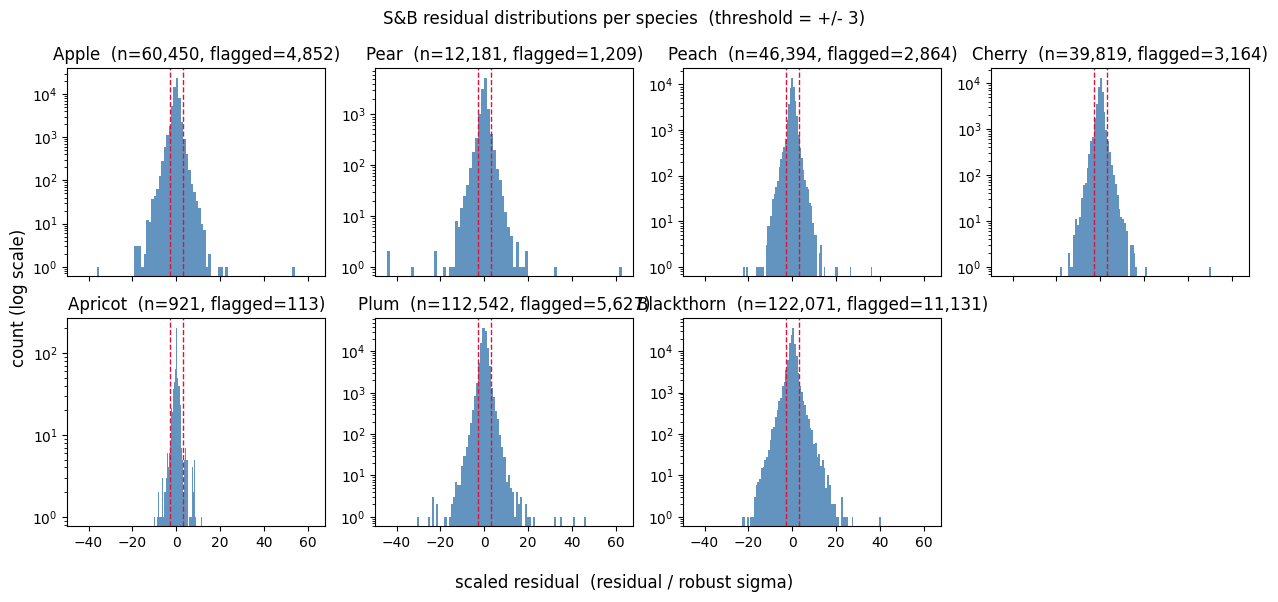

In [8]:
import matplotlib.pyplot as plt

species_ids = [sid for sid, _ in FRUIT_TREE_SPECIES]
n = len(species_ids)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows),
                         sharex=True)
axes_flat = list(axes.flat)
for ax, sid in zip(axes_flat, species_ids):
    d = df_flat[(df_flat[KEY_SPECIES_ID] == sid) & df_flat['scored']]
    name = name_by_id[sid]
    if d.empty:
        ax.text(0.5, 0.5, 'no scored data', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(name)
        continue
    ax.hist(d['scaled'], bins=80, color='steelblue', alpha=0.85)
    ax.axvline( SB_SIGMA_THRESHOLD, color='crimson', lw=1, ls='--')
    ax.axvline(-SB_SIGMA_THRESHOLD, color='crimson', lw=1, ls='--')
    ax.set_title(f'{name}  (n={len(d):,d}, flagged={int(d["flagged"].sum()):,d})')
    ax.set_yscale('log')
for ax in axes_flat[n:]:
    ax.set_visible(False)
fig.supxlabel('scaled residual  (residual / robust sigma)')
fig.supylabel('count (log scale)')
fig.suptitle(
    f'S&B residual distributions per species  '
    f'(threshold = +/- {SB_SIGMA_THRESHOLD:g})'
)
plt.tight_layout()
plt.show()

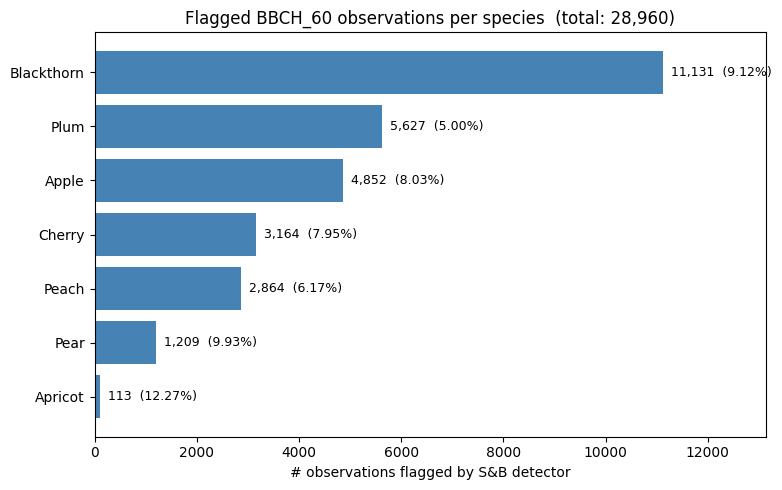

In [9]:
order = by_species.sort_values('flagged')
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(order['species'], order['flagged'], color='steelblue')
for y, (n, p) in enumerate(zip(order['flagged'], order['pct_flagged_of_scored'])):
    label = f'  {int(n):,d}'
    if pd.notna(p):
        label += f'  ({p:.2f}%)'
    ax.text(n, y, label, va='center', fontsize=9)
ax.set_xlabel('# observations flagged by S&B detector')
ax.set_title(
    f'Flagged BBCH_60 observations per species  '
    f'(total: {int(order["flagged"].sum()):,d})'
)
ax.margins(x=0.18)
plt.tight_layout()
plt.show()

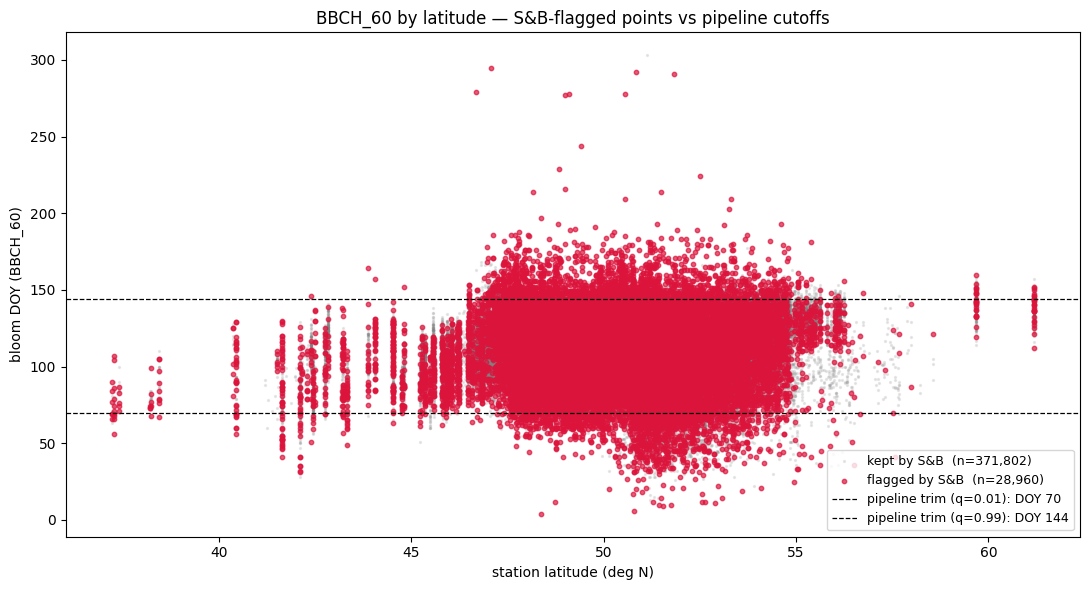

In [10]:
# Join lat onto each observation (single PEP725 src, so loc_id is unique)
loc_to_lat = (
    dfs_raw['locations']
        .reset_index(level='src', drop=True)['lat']
)
df_geo = df_flat.assign(lat=df_flat[KEY_LOC_ID].map(loc_to_lat))

# Pipeline cutoffs computed on the same pool (all 9 species, BBCH_60)
q_lo = float(df_geo['doy'].quantile(0.01))
q_hi = float(df_geo['doy'].quantile(0.99))

fig, ax = plt.subplots(figsize=(11, 6))
kept    = df_geo[~df_geo['flagged']]
flagged = df_geo[ df_geo['flagged']]
ax.scatter(kept['lat'],    kept['doy'],    s=2, alpha=0.15, color='grey',
           label=f'kept by S&B  (n={len(kept):,d})')
ax.scatter(flagged['lat'], flagged['doy'], s=10, alpha=0.7, color='crimson',
           label=f'flagged by S&B  (n={len(flagged):,d})')
ax.axhline(q_lo, color='black', ls='--', lw=0.9,
           label=f'pipeline trim (q=0.01): DOY {q_lo:.0f}')
ax.axhline(q_hi, color='black', ls='--', lw=0.9,
           label=f'pipeline trim (q=0.99): DOY {q_hi:.0f}')
ax.set_xlabel('station latitude (deg N)')
ax.set_ylabel('bloom DOY (BBCH_60)')
ax.set_title('BBCH_60 by latitude — S&B-flagged points vs pipeline cutoffs')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()